In [8]:
# ── Parámetros a ajustar manualmente ──────────────────────────────────────────
P0_BINARY   = 0.05
P1_BINARY   = 150
P0_RRLYRAE  = 0.15
P1_RRLYRAE  = 1.0
P0_CEFEID   = 0.2
P1_CEFEID   = 150
P_NUM       = 10000
N_SAMPLE    = 5
RANDOM_SEED = 21

ACTIVE_TYPES    = ["binary"]  # Subconjunto a procesar ("binary", "rrlyrae", "cefeid")
PLOT_ENTROPIES  = True  # Graficar periodograma de entropía, se recomienda solo con N_SAMPLE pequeños
PLOT_LIGHTCURVE = True  # Graficar curva de luz de la mejor solución

# ── Divisiones de grilla por tipo (t_parts=fases, u_parts=magnitudes) ─────────
GRID_PARTS = {
    "binary":  {"L": 8, "K": 8},
    "rrlyrae": {"L": 7, "K": 7},
    "cefeid":  {"L": 10, "K": 10},
}
# ──────────────────────────────────────────────────────────────────────────────

In [9]:
# Seleccionar algoritmo de mínima entropía
import least_entropy_threshold_claude as le


Procesando: BINARY
  Muestra: 5 de 10 archivos disponibles


100%|██████████| 9220/9220 [00:15<00:00, 595.18it/s]


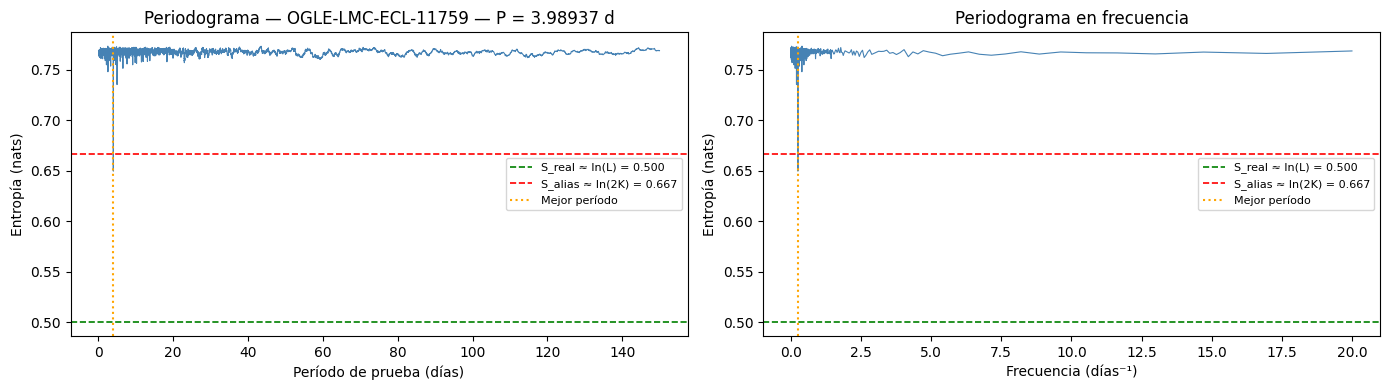

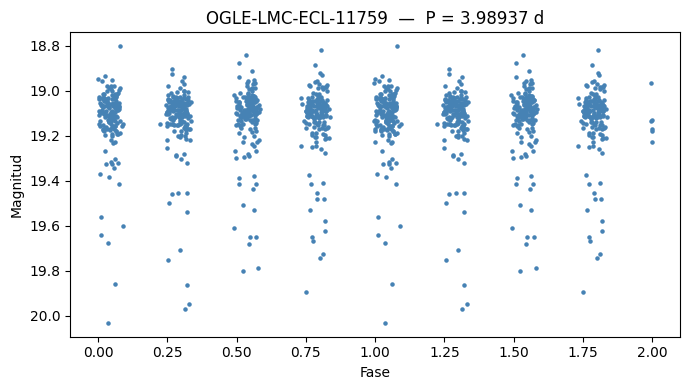

100%|██████████| 9161/9161 [00:14<00:00, 646.87it/s]]


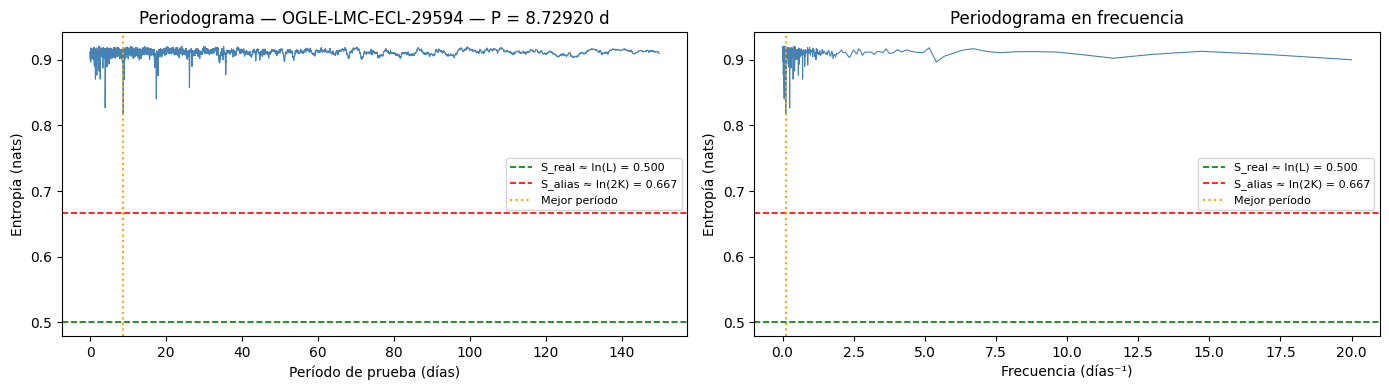

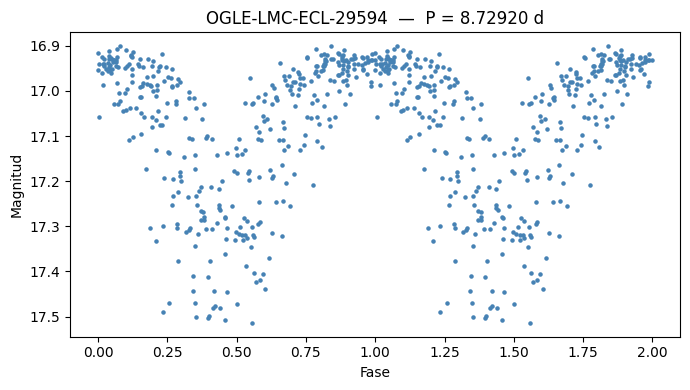

100%|██████████| 9245/9245 [00:14<00:00, 639.76it/s]]


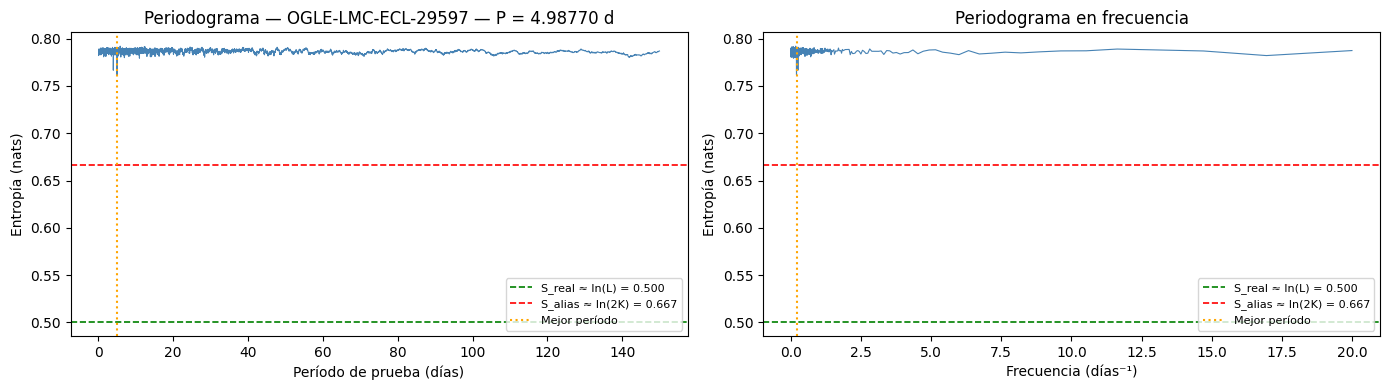

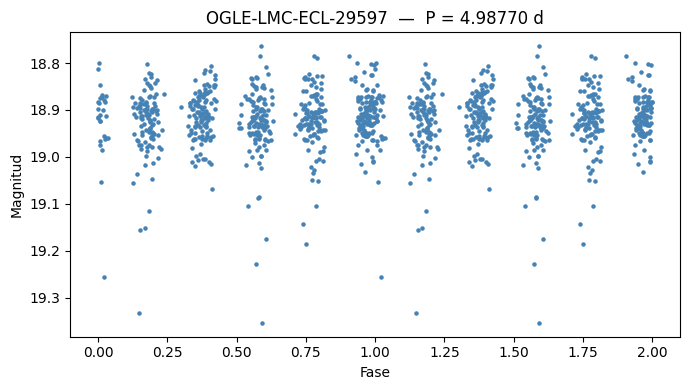

100%|██████████| 9190/9190 [00:14<00:00, 622.33it/s]]


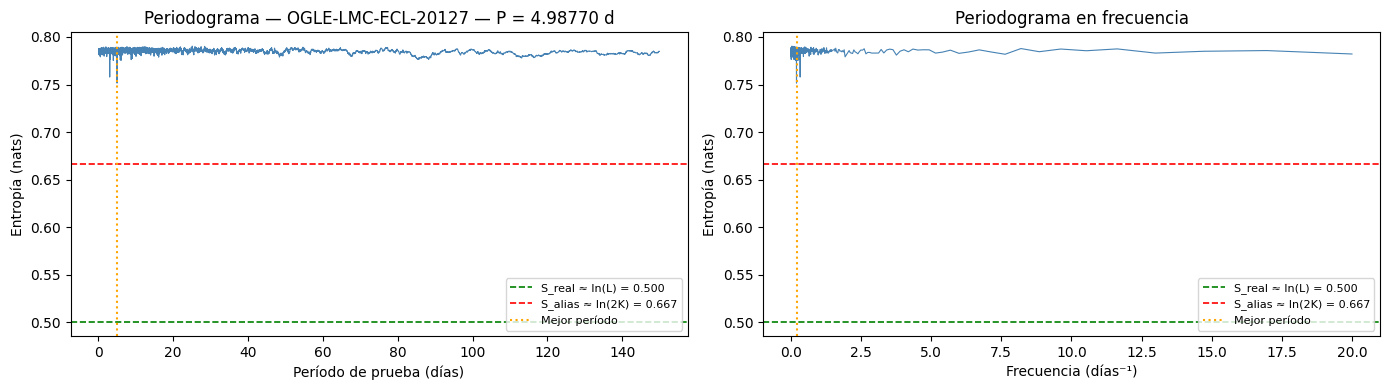

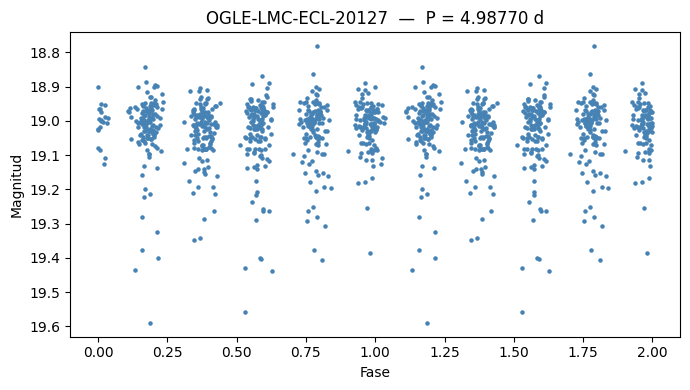

100%|██████████| 9175/9175 [00:13<00:00, 660.52it/s]]


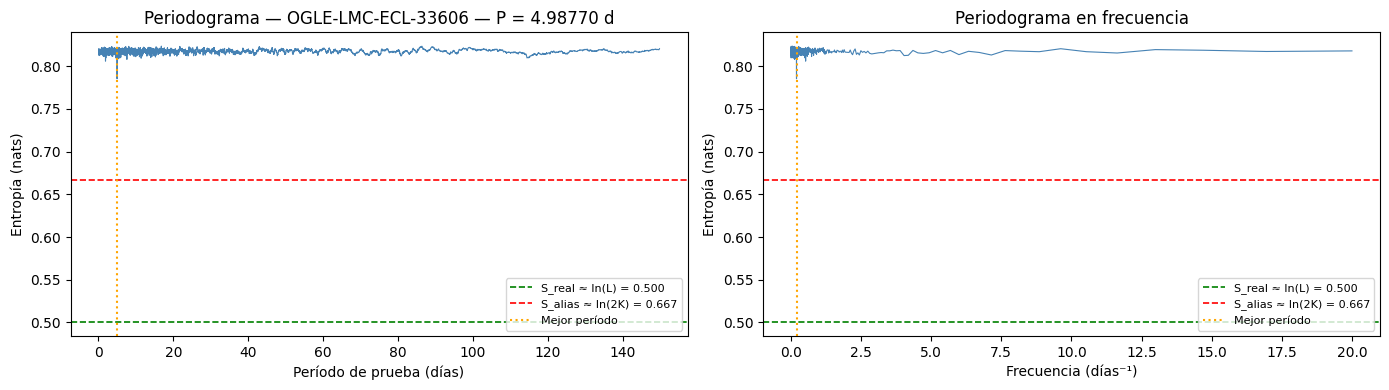

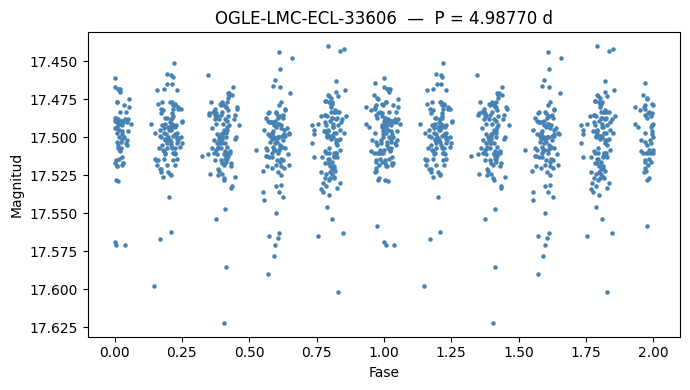

binary: 100%|██████████| 5/5 [01:17<00:00, 15.55s/it]


Listo. Resultados en df_results.
tipo
binary    0.0
Name: recovery_rate, dtype: float64
Guardado en: resultados_masivos/resultados_20260423_233006.csv


In [10]:
# Loop principal
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import testing as tst
import random
from datetime import datetime

COLLECTIONS = {
    "binary": {
        "dat_dir":  "ogle_collection/binaries_phot",
        "ref_file": "ogle_collection/binaries.txt",
        "p_col":    "P",
        "p0": P0_BINARY,
        "p1": P1_BINARY,
    },
    "rrlyrae": {
        "dat_dir":  "ogle_collection/rrlyrae_phot",
        "ref_file": "ogle_collection/rrlyrae.txt",
        "p_col":    "P_1",
        "p0": P0_RRLYRAE,
        "p1": P1_RRLYRAE,
    },
    "cefeid": {
        "dat_dir":  "ogle_collection/classical_cefeids_phot",
        "ref_file": "ogle_collection/classical_cefeids.txt",
        "p_col":    "P_1",
        "p0": P0_CEFEID,
        "p1": P1_CEFEID,
    },
}


def load_reference(ref_file, p_col):
    df_ref = pd.read_csv(ref_file, skiprows=6, sep=r"\s+")
    ref = {}
    for _, row in df_ref.iterrows():
        ref[str(row["ID"])] = {
            "mag_I":  row["I"],
            "p_true": row[p_col],
        }
    return ref


def plot_lightcurve(data, phases1, phases2, best_period, nombre):
    all_phases = np.concatenate([phases1, phases2])
    all_u      = np.concatenate([data["u"], data["u"]])

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(all_phases, all_u, s=5, color="steelblue")
    ax.set_title(f"{nombre}  —  P = {best_period:.5f} d")
    ax.set_xlabel("Fase")
    ax.set_ylabel("Magnitud")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


# ── Validar ACTIVE_TYPES ──────────────────────────────────────────────────────
invalid = set(ACTIVE_TYPES) - set(COLLECTIONS)
if invalid:
    raise ValueError(f"Tipos no reconocidos en ACTIVE_TYPES: {invalid}")

# ── Bucle principal ───────────────────────────────────────────────────────────
all_results = []

for tipo, cfg in COLLECTIONS.items():
    if tipo not in ACTIVE_TYPES:
        continue

    print(f"\n{'='*50}")
    print(f"Procesando: {tipo.upper()}")
    print(f"{'='*50}")

    try:
        ref = load_reference(cfg["ref_file"], cfg["p_col"])
    except Exception as e:
        print(f"  [ERROR] No se pudo cargar la referencia {cfg['ref_file']}: {e}")
        continue

    archivos = [f for f in os.listdir(cfg["dat_dir"]) if f.endswith(".dat")]

    if N_SAMPLE is not None and N_SAMPLE < len(archivos):
        rng = random.Random(RANDOM_SEED)
        archivos = rng.sample(archivos, N_SAMPLE)
        print(f"  Muestra: {N_SAMPLE} de {len(archivos) + N_SAMPLE} archivos disponibles")
    else:
        print(f"  Procesando todos los archivos: {len(archivos)}")

    for archivo in tqdm(archivos, desc=tipo):
        nombre = archivo.split(".")[0]
        ruta   = os.path.join(cfg["dat_dir"], archivo)

        if nombre not in ref:
            print(f"  [WARN] {nombre} no encontrado en {cfg['ref_file']}, omitiendo.")
            continue

        p_true = ref[nombre]["p_true"]
        mag_I  = ref[nombre]["mag_I"]

        if not (cfg["p0"] <= p_true <= cfg["p1"]):
            print(f"  [SKIP] {nombre} — p_true={p_true:.4f} fuera de [{cfg['p0']}, {cfg['p1']}]")
            continue

        try:
            data = pd.read_csv(ruta, sep=" ", lineterminator="\n", names=("t", "u", "inc_u"))
        except Exception as e:
            print(f"  [ERROR] {nombre} — no se pudo leer el .dat: {e}")
            continue

        try:
            p_found, min_entropy, phases1, phases2, periods, entropies = le.find_best_period(
                data,
                p0=cfg["p0"], p1=cfg["p1"],
                p_num=P_NUM,
                L=GRID_PARTS[tipo]["L"],
                K=GRID_PARTS[tipo]["K"],
                plot_entropies=PLOT_ENTROPIES,
                name=nombre,
            )
        except Exception as e:
            print(f"  [ERROR] {nombre} — fallo en find_best_period: {e}")
            continue

        if PLOT_LIGHTCURVE:
            plot_lightcurve(data, phases1, phases2, p_found, nombre)

        error    = tst.period_error(p_found, p_true)
        multiple = tst.which_multiple(p_found, p_true)

        all_results.append({
            "id":       nombre,
            "tipo":     tipo,
            "mag_I":    mag_I,
            "p_true":   p_true,
            "p_found":  p_found,
            "error":    error,
            "multiple": multiple,
            "success":  error < 0.05,
        })

df_results = pd.DataFrame(all_results)
print("\nListo. Resultados en df_results.")
print(df_results.groupby("tipo")["success"].mean().rename("recovery_rate"))

# ── Exportar ──────────────────────────────────────────────────────────────────
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("resultados_masivos", exist_ok=True)
df_results.to_csv(f"resultados_masivos/resultados_{timestamp}.csv", index=False)

params = {
    "timestamp": timestamp,
    "P0_BINARY": P0_BINARY, "P1_BINARY": P1_BINARY,
    "P0_RRLYRAE": P0_RRLYRAE, "P1_RRLYRAE": P1_RRLYRAE,
    "P0_CEFEID": P0_CEFEID, "P1_CEFEID": P1_CEFEID,
    "P_NUM": P_NUM, "N_SAMPLE": N_SAMPLE, "RANDOM_SEED": RANDOM_SEED,
    "ACTIVE_TYPES": str(ACTIVE_TYPES),
    "GRID_PARTS": str(GRID_PARTS),
}
pd.DataFrame([params]).to_csv(f"resultados_masivos/params_{timestamp}.csv", index=False)
print(f"Guardado en: resultados_masivos/resultados_{timestamp}.csv")

In [11]:
# ── Exportar resultados ───────────────────────────────────────────────────────
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("resultados_masivos", exist_ok=True)

df_results.to_csv(f"resultados_masivos/resultados_{timestamp}.csv", index=False)

params = {
    "timestamp":      timestamp,
    "P0_BINARY":      P0_BINARY,
    "P1_BINARY":      P1_BINARY,
    "P0_RRLYRAE":     P0_RRLYRAE,
    "P1_RRLYRAE":     P1_RRLYRAE,
    "P0_CEFEID":      P0_CEFEID,
    "P1_CEFEID":      P1_CEFEID,
    "P_NUM":          P_NUM,
    "N_SAMPLE":       N_SAMPLE,
    "RANDOM_SEED":    RANDOM_SEED,
    "ACTIVE_TYPES":   str(ACTIVE_TYPES),
    "PLOT_ENTROPIES": PLOT_ENTROPIES,
    "PLOT_LIGHTCURVE":PLOT_LIGHTCURVE,
    "GRID_PARTS":     str(GRID_PARTS),
}
pd.DataFrame([params]).to_csv(f"resultados_masivos/params_{timestamp}.csv", index=False)
print(f"Guardado en:    resultados_masivos/resultados_{timestamp}.csv")
print(f"Parámetros en: resultados_masivos/params_{timestamp}.csv")

Guardado en:    resultados_masivos/resultados_20260423_233006.csv
Parámetros en: resultados_masivos/params_20260423_233006.csv


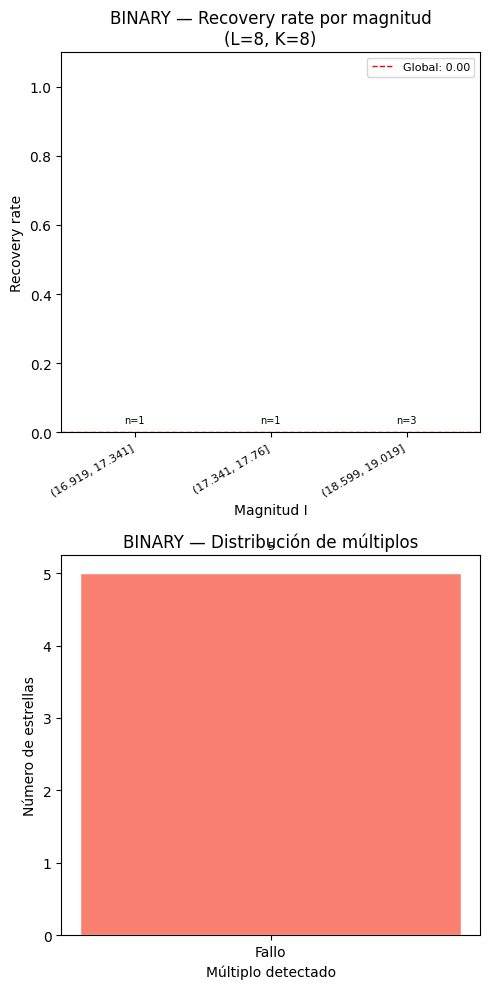

Gráficas guardadas en: resultados_masivos/recovery_bars_20260423_233006.png


In [12]:
# ── Gráficas de recovery rate ─────────────────────────────────────────────────
n_tipos = len(ACTIVE_TYPES)
fig, axes = plt.subplots(2, n_tipos, figsize=(5 * n_tipos, 10))

# Asegurar siempre array 2D aunque haya un solo tipo
if n_tipos == 1:
    axes = axes.reshape(2, 1)

for col, tipo in enumerate(ACTIVE_TYPES):
    df_tipo = df_results[df_results["tipo"] == tipo]
    L = GRID_PARTS[tipo]["L"]
    K = GRID_PARTS[tipo]["K"]

    # ── Recovery rate por bin de magnitud ─────────────────────────────────
    ax_mag   = axes[0, col]
    bins     = pd.cut(df_tipo["mag_I"], bins=5)
    recovery = df_tipo.groupby(bins, observed=True)["success"].mean()
    counts   = df_tipo.groupby(bins, observed=True)["success"].count()

    x    = range(len(recovery))
    bars = ax_mag.bar(x, recovery.values, color="steelblue", edgecolor="white")
    ax_mag.set_xticks(x)
    ax_mag.set_xticklabels([str(b) for b in recovery.index], rotation=30, ha="right", fontsize=8)
    ax_mag.set_ylim(0, 1.1)
    ax_mag.set_xlabel("Magnitud I")
    ax_mag.set_ylabel("Recovery rate")
    ax_mag.set_title(f"{tipo.upper()} — Recovery rate por magnitud\n(L={L}, K={K})")
    ax_mag.axhline(df_tipo["success"].mean(), color="red", linestyle="--", linewidth=1,
                   label=f"Global: {df_tipo['success'].mean():.2f}")
    ax_mag.legend(fontsize=8)

    for bar, n in zip(bars, counts.values):
        ax_mag.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f"n={n}", ha="center", va="bottom", fontsize=7)

    # ── Distribución de múltiplos ─────────────────────────────────────────
    ax_mul     = axes[1, col]
    mul_counts = df_tipo["multiple"].value_counts(dropna=False).sort_index()
    labels     = [str(m) if m is not None else "Fallo" for m in mul_counts.index]
    colors     = ["salmon" if l == "Fallo" else "mediumseagreen" for l in labels]

    ax_mul.bar(labels, mul_counts.values, color=colors, edgecolor="white")
    ax_mul.set_xlabel("Múltiplo detectado")
    ax_mul.set_ylabel("Número de estrellas")
    ax_mul.set_title(f"{tipo.upper()} — Distribución de múltiplos")

    for i, (label, val) in enumerate(zip(labels, mul_counts.values)):
        ax_mul.text(i, val + 0.3, str(val), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(f"resultados_masivos/recovery_bars_{timestamp}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráficas guardadas en: resultados_masivos/recovery_bars_{timestamp}.png")